In [1]:
%load_ext jupyter_black

In [2]:
from sklearn import metrics

In [3]:
from data_loader import *
import matplotlib.pyplot as plt
from common import results_folder, write_excel
from sklearn.utils import resample
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
dl = DataLoader()

dependent_variables = [
    "first_attempt_is_poor_quintile",
    "first_attempt_is_excellent_quintile",
    "last_attempt_is_poor_quintile",
    "last_attempt_is_excellent_quintile",
]

independent_variables = ["z_score_Invulvraag", "z_score_Meerkeuzevraag"]


dep_var_labels = {
    "first_attempt_is_poor_quintile": "Poor performing (first sitting)",
    "first_attempt_is_excellent_quintile": "Excellent performing (first sitting)",
    "last_attempt_is_poor_quintile": "Poor performing (last sitting)",
    "last_attempt_is_excellent_quintile": "Excellent performing (last sitting)",
}


def savefig(fig, path):
    for ext in (".pdf", ".png"):
        fig.savefig(str(path) + ext, dpi=300)

In [5]:
def calculate_paired_roc_diff(y_test, vsaq, mcq, n_bootstraps=20000):
    boot_aucs = []

    rng = np.random.RandomState(42)
    for _ in range(n_bootstraps):
        y_res, vsaq_res, mcq_res = resample(
            y_test, vsaq, mcq, replace=True, random_state=rng
        )

        if len(np.unique(y_res)) < 2:
            continue

        vsaq_val = metrics.roc_auc_score(y_res, vsaq_res)
        mcq_val = metrics.roc_auc_score(y_res, mcq_res)
        boot_aucs.append(vsaq_val - mcq_val)

    sorted_aucs = np.array(boot_aucs)
    sorted_aucs.sort()
    confidence_lower = np.percentile(sorted_aucs, 2.5)
    confidence_upper = np.percentile(sorted_aucs, 97.5)

    return confidence_upper, confidence_lower

In [6]:
colors = ["red", "blue"]
linestyles = ["dotted", "dashed"]


def add_headers(
    fig,
    *,
    row_headers=None,
    col_headers=None,
    row_pad=1,
    col_pad=5,
    rotate_row_headers=True,
    **text_kwargs,
):
    # Based on https://stackoverflow.com/a/25814386

    axes = fig.get_axes()

    for ax in axes:
        sbs = ax.get_subplotspec()

        # Putting headers on cols
        if (col_headers is not None) and sbs.is_first_row():
            ax.annotate(
                col_headers[sbs.colspan.start],
                xy=(0.5, 1),
                xytext=(0, col_pad),
                xycoords="axes fraction",
                textcoords="offset points",
                ha="center",
                va="baseline",
                fontweight="bold",
                **text_kwargs,
            )

        # Putting headers on rows
        if (row_headers is not None) and sbs.is_first_col():
            ax.annotate(
                row_headers[sbs.rowspan.start],
                xy=(0, 0.5),
                xytext=(-ax.yaxis.labelpad - row_pad, 0),
                xycoords=ax.yaxis.label,
                textcoords="offset points",
                ha="right",
                va="center",
                rotation=rotate_row_headers * 90,
                fontweight="bold",
                **text_kwargs,
            )


def generate_roc_curve_cohort(loader):
    loader = list(loader)

    fig, axss = plt.subplots(
        figsize=(12, 9),
        ncols=len(dependent_variables),
        nrows=len(loader),
    )
    scores = []
    labels = []
    for (label, data), axs in zip(loader, axss):
        labels.append(format_text(label))
        _, _, score = generate_roc_curve_total(label, data, fig, axs)
        scores.append(score)

    add_headers(
        fig,
        row_headers=labels,
        col_headers=[format_label(target) for target in dependent_variables],
        col_pad=50,
    )

    return fig, axss, pd.concat(scores)


def format_label(label):
    return dep_var_labels[label]


def format_text(label):
    label = label.replace("_", " ")
    return label[0].upper() + label[1:]


def generate_roc_curve_total(
    label, data, fig=None, axs=None, ns_hoffset=0.0, ns_voffset=0.0
):
    scores = []
    # label = format_label(label)
    if axs is None:
        fig, axs = plt.subplots(
            figsize=(12, 3),
            ncols=len(dependent_variables),
        )

    for target, ax in zip(dependent_variables, axs):
        title = ""
        coefficient = -1 if "poor" in target else 1

        cu, cl = calculate_paired_roc_diff(
            data[target],
            coefficient * data["z_score_Invulvraag"],
            coefficient * data["z_score_Meerkeuzevraag"],
        )
        for dep, color, ls in zip(independent_variables, colors, linestyles):
            target_label = "VSAQ" if dep == "z_score_Invulvraag" else "MCQ"
            title = title + "\n" if title != "" else title
            # fpr, trc, _ = metrics.roc_curve(data[target], coefficient * data[dep])
            # ax.step(fpr, trc, color=color, label=target_label)
            ax.set_aspect("equal")
            ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.0])

            metrics.RocCurveDisplay.from_predictions(
                data[target],
                coefficient * data[dep],
                color=color,
                # color="black",
                ls=ls,
                label=target_label,
                ax=ax,
            )

            score = metrics.roc_auc_score(data[target], coefficient * data[dep])
            title += f" {target_label}: {score:.2f}"
            scores.append((label, format_label(target), target_label, score))
        scores.append((label, format_label(target), "Diff CL", cl))
        scores.append((label, format_label(target), "Diff CU", cu))

        signficance = ""  # "*" if cl > 0 else ""

        if cl < 0:
            ax.annotate(
                "NS",
                xy=(1.08 + ns_hoffset, 1.13 + ns_voffset),
                xycoords="axes fraction",
                ha="right",
                va="top",
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"
                ),
            )

        title += f"\nCI{signficance}: [{cl:.3f}–{cu:.3f}]"
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(title)
        ax.legend(loc="lower right")
    return (
        fig,
        axs,
        pd.DataFrame(scores, columns=["Group", "Target", "Question type", "ROC AUC"]),
    )

In [7]:
def transform(scores):
    def format_ci(row):
        return f"{row['ROC AUC']:.2f} [{row['CL']:.2f}–{row['CU']:.2f}]"

    s = (
        scores.set_index(["Group", "Target", "Question type"])
        # .apply(format_ci, axis=1)
        .unstack(level=2).sort_index()
    ).droplevel(axis=1, level=0)
    return s.loc[:, ["VSAQ", "MCQ", "Diff CL", "Diff CU"]]


dfs = {}

Loading RM 2021, ejected 0 for gpa availability, 30 for having 75% of ects available, resulting in 322
Loading RM 2022, ejected 0 for gpa availability, 3 for having 75% of ects available, resulting in 295
Loading RM 2023, ejected 0 for gpa availability, 7 for having 75% of ects available, resulting in 285


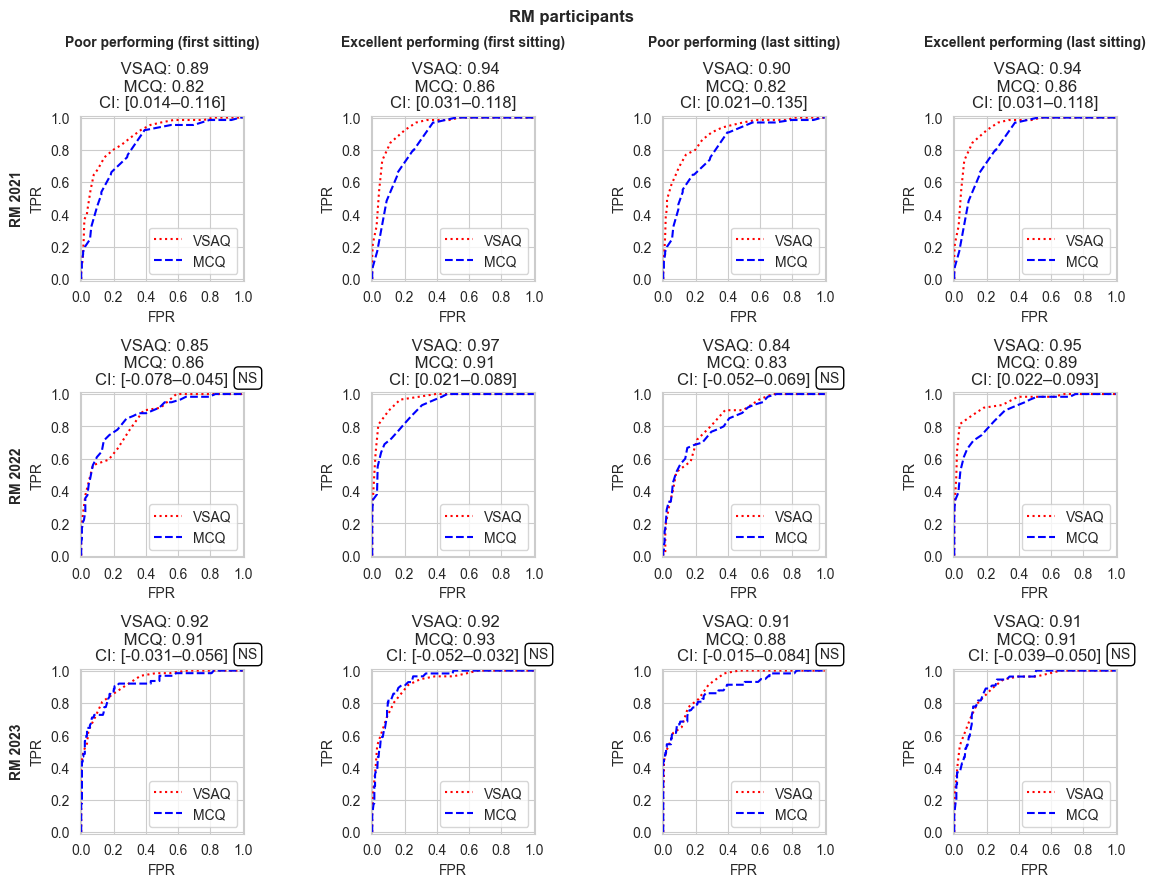

In [8]:
fig, axss, scores = generate_roc_curve_cohort(dl.rm_per_cohort())

label = "RM per cohort"

fig.suptitle("RM participants", fontweight="bold")

fig.tight_layout()

scores = transform(scores)

savefig(fig, results_folder / f"roc_curve_{label.replace(" ", "_").lower()}")

dfs[label] = scores

Loading RM 2021_DA 2022, ejected 0 for gpa availability, 4 for having 75% of ects available, resulting in 282
Loading RM 2022_DA 2023, ejected 0 for gpa availability, 1 for having 75% of ects available, resulting in 255
Loading RM 2023_DA 2024, ejected 0 for gpa availability, 6 for having 75% of ects available, resulting in 260


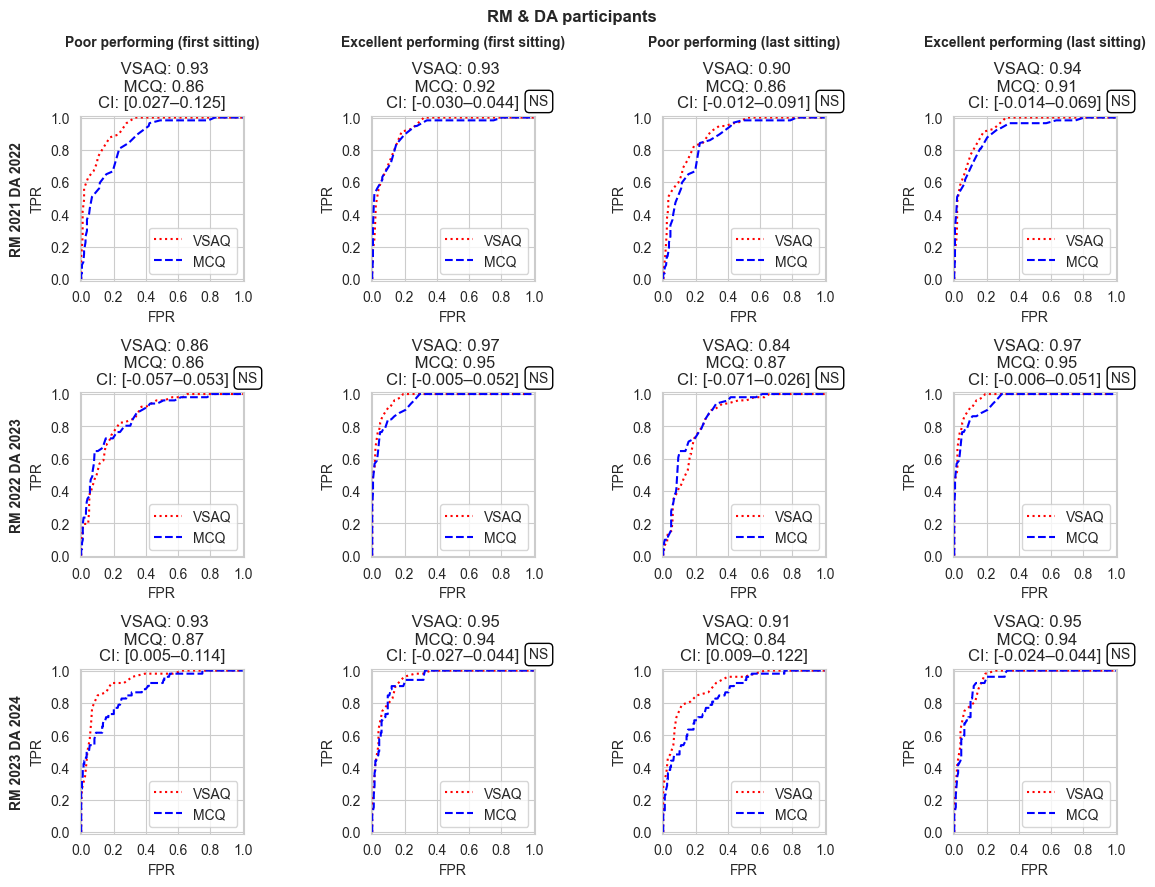

In [9]:
fig, axss, scores = generate_roc_curve_cohort(dl.rm_dm_per_cohort())
label = "RM DM per cohort"

fig.suptitle("RM & DA participants", fontweight="bold")

fig.tight_layout()
scores = transform(scores)

savefig(fig, results_folder / f"roc_curve_{label.replace(" ", "_").lower()}")

dfs[label] = scores

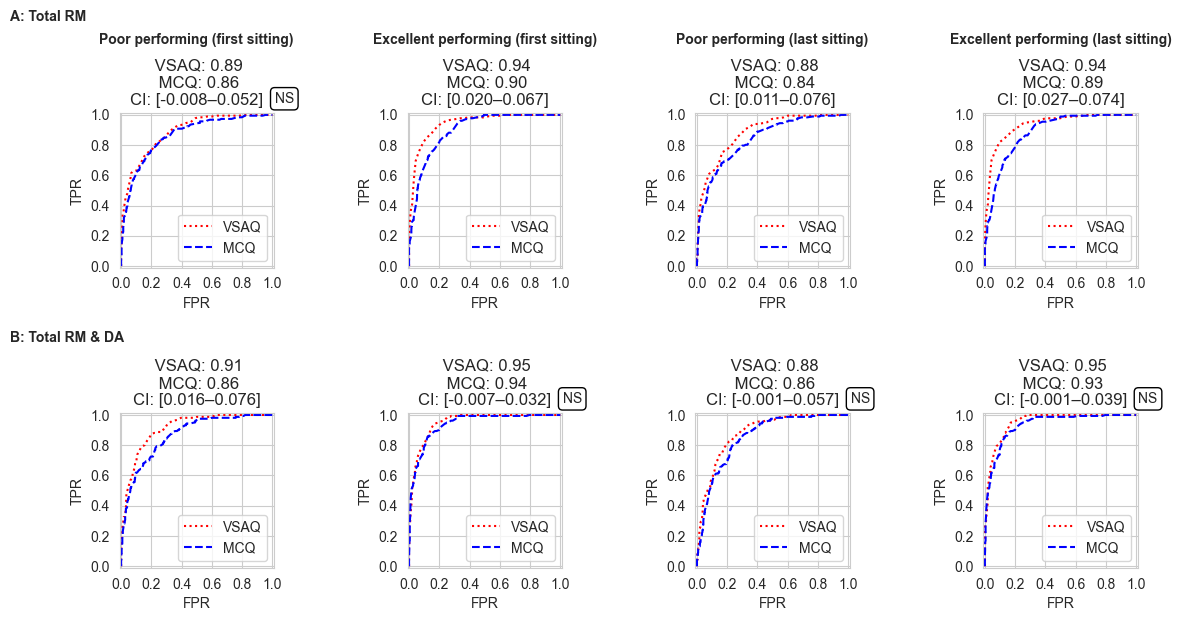

In [10]:
fig, axss = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))


_, _, scores = generate_roc_curve_total(
    "RM Total",
    dl.rm_total(),
    fig=fig,
    axs=axss[0],
    ns_hoffset=0.05,
    ns_voffset=0.01,
)

label = "Totals"

fig.tight_layout()
scores_rm = transform(scores)
labels = ["RM Total", "RM DA Total"]


_, _, scores = generate_roc_curve_total(
    "RM DA Total",
    dl.rm_dm_total(),
    fig=fig,
    axs=axss[1],
    ns_hoffset=0.05,
    ns_voffset=0.01,
)


scores_rm_dm = transform(scores)

scores = pd.concat([scores_rm, scores_rm_dm])

add_headers(
    fig,
    col_headers=[format_label(target) for target in dependent_variables],
    col_pad=50,
)


row_headers = ["A: Total RM", "B: Total RM & DA"]


row_pad = 0
axes = fig.get_axes()
for ax in axes:
    sbs = ax.get_subplotspec()

    if (row_headers is not None) and sbs.is_first_col():
        ax.annotate(
            row_headers[sbs.rowspan.start],
            xy=(-6, 21 if sbs.rowspan.start == 0 else 19.5),
            xytext=(-ax.yaxis.labelpad - row_pad, 0),
            xycoords=ax.xaxis.label,
            textcoords="offset points",
            ha="left",
            va="center",
            fontweight="bold",
            # **text_kwargs,
        )
fig.tight_layout(h_pad=4)

savefig(fig, results_folder / f"roc_curve_{label.lower()}")


dfs[label] = scores

## 

In [11]:
write_excel(dfs, results_folder / "ROC_AUC_scores.xlsx")